# Nomor 1a
Lakukan Exploratory Data Analysis (EDA) untuk memahami dan mengidentifikasi
masalah pada dataset anda. Lakukan pre-processing pada dataset anda sesuai dengan hasil EDA anda,
termasuk memisahkan dataset anda menjadi train, val, dan test dengan proporsi 70:10:20.

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [ ]:
df = pd.read_parquet('1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [ ]:
df.shape

(2000, 18)

In [ ]:
df.columns

Index(['Sales_ID', 'name', 'year', 'selling_price', 'km_driven', 'Region',
       'State or Province', 'City', 'fuel', 'seller_type', 'transmission',
       'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold'],
      dtype='object')

## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

### Check Duplicates

In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Check Inconsistent

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

Sales_ID: [1933 4901 2802 ...  742  169 5407]

name: ['Maruti' 'Ford' 'Honda' 'Chevrolet' 'Renault' 'Hyundai' 'Volkswagen'
 'Mahindra' 'Datsun' 'Skoda' 'Tata' 'Toyota' 'Mercedes' 'Volvo' 'BMW'
 'Jeep' 'Audi' 'Jaguar' 'Mitsubishi' 'Fiat' 'Land' 'Nissan' 'Force'
 'Lexus' 'Isuzu' 'Daewoo' 'MG']

year: [2013 2004 2017 2016 2019 2015 2007 2018 2014 2011 2012 2009 2008 2010
 2020 2005 2006 2000 2003 1999 2002 3011]

selling_price: [  4500.     4000.     8199.99   6750.     1600.     5300.     5500.
   3250.     3600.     5200.     5000.     8500.     3500.     2600.
   2000.     3800.     8800.     8600.     2500.     2150.     1800.
   9400.     1500.     5900.     2420.     9000.     1850.    12650.
   4349.99   7100.     6500.     7000.    10000.     1750.     4800.
   5350.     1300.     1480.     9500.     4099.99   6000.     3000.
   8000.     3950.     9199.99   7250.    11900.     9699.99   5510.
   1250.     5150.     2950.     6900.     1700.     5800.    38000.
    930.     2700. 

### Handle Inconsistent

In [ ]:
# mileage
df['mileage'] = df['mileage'].str.replace(',', '.', regex=False)

# Change data type from string to float
df['mileage'] = df['mileage'].astype(float)

Ditemukan bahwa kolom mileage memiliki format yang tidak konsisten, seperti penggunaan tanda koma (,) sebagai desimal (contoh: "15,3") dan titik (.) sebagai desimal (contoh: "18.48"). Untuk menyeragamkan format data, seluruh tanda koma (,) diubah menjadi titik (.) sehingga dapat dikonversi ke tipe numerik (float).

In [ ]:
# torque
df['torque'] = (df['torque'].astype(str).str.lower().str.replace(',', '', regex=False).str.extract(r'(\d+\.?\d*)'))
df['torque'] = pd.to_numeric(df['torque'], errors='coerce')

Kolom torque memiliki format yang sangat tidak konsisten, dengan berbagai variasi satuan dan penulisan, seperti: "114Nm@ 4000rpm", "24@ 1,900(kgm@ rpm)", "32.1kgm@ 2000rpm", "190 Nm at 1750 rpm"

Untuk menyederhanakan data dan memastikan kompatibilitas dengan model Artificial Neural Network, dilakukan ekstraksi nilai numerik utama dari setiap entri. Informasi tambahan seperti satuan (Nm/kgm) dan rpm diabaikan karena tidak digunakan dalam proses modeling.

### Anomaly

In [ ]:
print((df['year'] == 3011).sum())
df = df[df['year'] != 3011]

1


Dilakukan pengecekan terhadap nilai anomali pada kolom year dengan menghitung jumlah data yang bernilai 3011. Nilai tersebut dianggap tidak valid karena berada di luar rentang tahun yang wajar, sehingga baris data dengan nilai tersebut dihapus dari dataset untuk menjaga kualitas data.

### Check Missing Value

In [ ]:
df = df.copy()

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

df = df.replace(['NA', 'N/A', 'na', 'n/a', 'null', 'Null', 'nan', 'Nan', ''], np.nan)

df = df.replace(r'^\s*$', np.nan, regex=True)
print(df.isna().sum())

Sales_ID             0
name                 0
year                 0
selling_price        2
km_driven            0
Region               2
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         2
owner                0
mileage              2
engine               0
max_power            0
torque               0
seats                0
sold                 0
dtype: int64


Berdasarkan hasil pengecekan, ditemukan beberapa missing values pada beberapa kolom seperti selling_price, Region, transmission, dan mileage.
Jumlah missing values relatif kecil dibandingkan total dataset (kurang dari 1%), sehingga dilakukan penghapusan baris yang mengandung missing values menggunakan metode dropna(). Pendekatan ini dipilih untuk menjaga kualitas data tanpa menimbulkan bias dari proses imputasi.

### Handle Missing Value

In [ ]:
df = df.dropna(subset=['selling_price', 'Region', 'transmission', 'mileage'])

### Check Outliers

In [ ]:
cols = df.select_dtypes(include='number')

outliers = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outliers[col] = outlier_count

outliers

{'Sales_ID': 0,
 'year': 30,
 'selling_price': 144,
 'km_driven': 62,
 'mileage': 3,
 'engine': 303,
 'max_power': 136,
 'torque': 93,
 'seats': 412}

Ditemukan sejumlah outlier pada beberapa fitur numerik seperti engine, selling_price, dan seats. Untuk mengatasi hal ini tanpa menghilangkan terlalu banyak data, digunakan teknik capping (winsorization) berdasarkan metode IQR. Teknik ini membatasi nilai ekstrem ke dalam batas bawah dan atas sehingga distribusi data menjadi lebih stabil untuk pelatihan model Artificial Neural Network.

### Handle Outliers

In [ ]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df.loc[:, col] = df[col].clip(lower, upper)
    return df

### Check Target Distribution

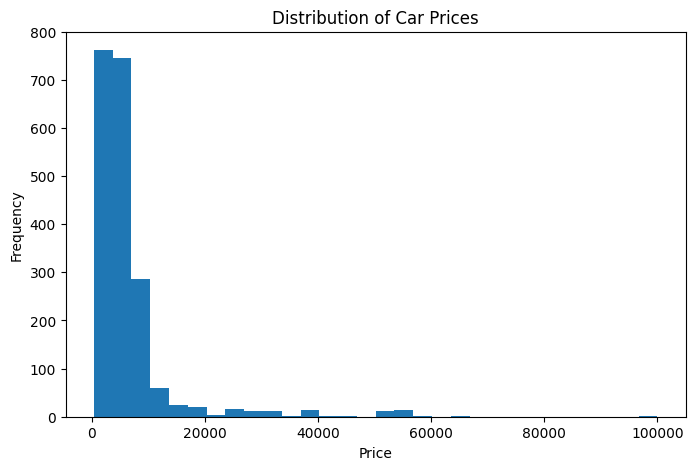

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Car Prices')
plt.show()

Distribusi yang skewed menunjukkan bahwa sebagian besar kendaraan memiliki harga yang relatif rendah, sementara hanya sedikit kendaraan dengan harga tinggi. Kondisi ini umum terjadi pada dataset harga dan dapat mempengaruhi performa model. Oleh karena itu, dilakukan transformasi logaritmik untuk menstabilkan distribusi dan meningkatkan kemampuan model dalam mempelajari pola data.

### Handle Skew

In [ ]:
df['selling_price'] = np.log1p(df['selling_price'])

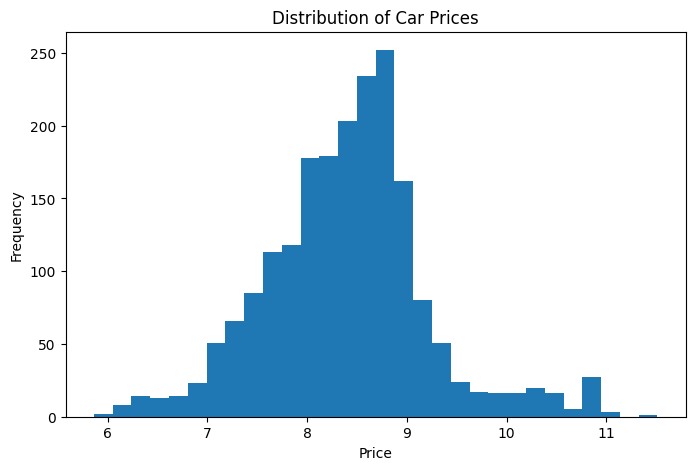

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Car Prices')
plt.show()

### Correlation Analysis

In [ ]:
from scipy.stats import pearsonr

num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    if col != 'selling_price':
        corr, p_value = pearsonr(df[col], df['selling_price'])
        print(f"{col}: correlation={corr:.3f}, p-value={p_value:.5f}")

Sales_ID: correlation=0.003, p-value=0.89078
year: correlation=0.699, p-value=0.00000
km_driven: correlation=-0.273, p-value=0.00000
mileage: correlation=-0.039, p-value=0.08221
engine: correlation=0.529, p-value=0.00000
max_power: correlation=0.734, p-value=0.00000
torque: correlation=0.686, p-value=0.00000
seats: correlation=0.195, p-value=0.00000


Berdasarkan analisis korelasi Pearson dan uji signifikansi (p-value), ditemukan bahwa fitur seperti max_power, torque, dan engine memiliki hubungan yang kuat dan signifikan terhadap harga mobil. Fitur km_driven menunjukkan hubungan negatif yang signifikan, yang berarti semakin tinggi jarak tempuh, harga mobil cenderung menurun. Sementara itu, fitur Sales_ID tidak memiliki hubungan dengan harga karena hanya merupakan identifier, sehingga dihapus dari dataset. Fitur mileage juga menunjukkan korelasi yang sangat lemah dan tidak signifikan, sehingga dipertimbangkan untuk dihapus.

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(df.groupby(col)['selling_price'].mean().sort_values())

name
Daewoo         6.758095
Mitsubishi     7.313887
Chevrolet      7.662066
Tata           8.001271
Datsun         8.015569
Fiat           8.086815
Maruti         8.093024
Ford           8.255303
Nissan         8.267851
Hyundai        8.301005
Renault        8.372705
Volkswagen     8.465104
Honda          8.590113
Skoda          8.597736
Mahindra       8.654393
Toyota         8.985153
Force          9.153582
Isuzu          9.548219
MG             9.741027
Mercedes       9.940041
Jeep           9.999965
Audi          10.186251
Jaguar        10.268152
Volvo         10.413952
BMW           10.427745
Land          10.714440
Lexus         10.849357
Name: selling_price, dtype: float64
Region
West       8.364216
Central    8.395936
East       8.405965
South      8.440692
Name: selling_price, dtype: float64
State or Province
Vermont                 8.068357
Kentucky                8.134111
South Carolina          8.142886
Wisconsin               8.165816
District of Columbia    8.201681
North

Analisis fitur kategorikal dilakukan dengan melihat rata-rata harga berdasarkan masing-masing kategori. Ditemukan bahwa fitur seperti name (brand mobil), transmission, fuel, seller_type, dan owner memiliki pengaruh terhadap harga mobil. Fitur name menunjukkan perbedaan harga yang signifikan antar merek, dimana merek premium seperti BMW dan Lexus memiliki harga lebih tinggi dibandingkan merek lainnya. Sementara itu, fitur seperti City dan State or Province memiliki jumlah kategori yang sangat banyak (high cardinality) dan tidak menunjukkan perbedaan yang signifikan, sehingga dihapus untuk menghindari kompleksitas model dan overfitting.

## Feature Selection

In [ ]:
drop_cols = ['Sales_ID', 'City', 'State or Province', 'mileage', 'Region', 'sold']
df = df.drop(columns=drop_cols)

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,engine,max_power,torque,seats
0,Maruti,2013,8.412055,41800,Petrol,Individual,Manual,First_Owner,1197,85.8,114.0,5
1,Ford,2004,8.294300,93415,Diesel,Dealer,Manual,First_Owner,2499,141.0,330.0,7
2,Honda,2017,9.012010,12000,Petrol,Individual,Manual,First_Owner,1199,88.7,110.0,5
3,Maruti,2016,8.817446,108000,Diesel,Dealer,Manual,First_Owner,1248,88.5,200.0,5
4,Maruti,2019,8.817446,5000,Petrol,Individual,Automatic,First_Owner,1197,83.1,115.0,5


Pada tahap ini dilakukan proses feature selection untuk memilih fitur-fitur yang relevan terhadap variabel target, yaitu selling_price. Proses ini bertujuan untuk meningkatkan performa model, mengurangi kompleksitas, serta menghindari overfitting. Pemilihan fitur dilakukan berdasarkan hasil analisis korelasi dan uji signifikansi, dimana fitur dengan korelasi sangat rendah dan tidak signifikan seperti mileage dihapus karena tidak memberikan kontribusi yang berarti. Selain itu, fitur yang bersifat identifier seperti Sales_ID juga dihapus karena tidak memiliki hubungan dengan harga mobil. Fitur dengan jumlah kategori yang sangat banyak seperti City dan State or Province dihapus karena dapat meningkatkan kompleksitas model dan berpotensi menyebabkan overfitting. Kemudian, fitur seperti sold dan Region juga dipertimbangkan untuk dihapus karena tidak menunjukkan perbedaan yang signifikan terhadap harga mobil.

## Split Data

In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop('selling_price', axis=1)
y = df['selling_price']

# train 70%, temp 30%
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)

# val 10%, test 20%
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=2/3, random_state=42)

print(x_train.shape, x_val.shape, x_test.shape)

(1393, 11) (199, 11) (399, 11)


Pada tahap preprocessing, dataset dibagi menjadi data training, validation, dan testing dengan proporsi 70:10:20. Pembagian ini bertujuan untuk memastikan model dapat dilatih, divalidasi, dan diuji secara optimal.

## Pipeline (Encoding + Scaling)

In [ ]:
num_cols = ['year', 'km_driven', 'engine', 'max_power', 'torque', 'seats']
cat_cols = ['name', 'fuel', 'seller_type', 'transmission', 'owner']

In [ ]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# numerical preprocessing
num_transformer = RobustScaler()

# categorical preprocessing
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num', RobustScaler(),
                                 ['year', 'km_driven', 'engine', 'max_power',
                                  'torque', 'seats']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['name', 'fuel', 'seller_type', 'transmission',
                                  'owner'])])

In [ ]:
# fit train
x_train_processed = preprocessor.fit_transform(x_train)

# transform val & test
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)

In [ ]:
print(x_train_processed.shape)
print(x_val_processed.shape)
print(x_test_processed.shape)

(1393, 46)
(199, 46)
(399, 46)


Dilakukan transformasi data menggunakan pipeline yang terdiri dari encoding untuk fitur kategorikal dan scaling untuk fitur numerikal. Encoding dilakukan menggunakan OneHotEncoder untuk mengubah data kategorikal menjadi numerik, sedangkan scaling dilakukan menggunakan RobustScaler untuk mengatasi pengaruh outlier pada data numerikal. Proses fitting hanya dilakukan pada data training untuk menghindari data leakage, dan kemudian diterapkan pada data validation dan testing.

# Nomor 1b
Buatlah 1 baseline model. Semua hidden layer wajib
menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari
dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model
tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

In [ ]:
input_dim = x_train_processed.shape[1]
print(input_dim)

46


## Baseline ANN (Keras)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(input_dim * 2, activation='relu'),
    Dense(input_dim * 2, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 92)             │         4,324 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 92)             │         8,556 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,973 (50.68 KB)

 Trainable params: 12,973 (50.68 KB)

 Non-trainable params: 0 (0.00 B)

Model ANN yang digunakan terdiri dari dua hidden layer dengan masing-masing 92 neuron dan fungsi aktivasi ReLU, serta satu output layer untuk prediksi nilai kontinu. Arsitektur ini telah memenuhi ketentuan soal dan memiliki total 12.973 parameter trainable, sehingga cukup efisien sebagai baseline model.

## Training >= 20 epoch

In [ ]:
history = model.fit(
    x_train_processed, y_train,
    validation_data=(preprocessor.transform(x_val), y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 30.6298 - mae: 4.8885 - val_loss: 3.4062 - val_mae: 1.3976
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4807 - mae: 0.8589 - val_loss: 0.5702 - val_mae: 0.5638
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5023 - mae: 0.4806 - val_loss: 0.3338 - val_mae: 0.4011
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3240 - mae: 0.3873 - val_loss: 0.2589 - val_mae: 0.3501
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2474 - mae: 0.3396 - val_loss: 0.1822 - val_mae: 0.2869
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1824 - mae: 0.2905 - val_loss: 0.1469 - val_mae: 0.2578
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1452 - mae: 0.2634 - val_loss: 0.1230 - val_mae: 0.2341
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1168 - mae: 0.2402 - val_loss: 0.1037 - val_mae: 0.2169
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0980 - mae:

Berdasarkan hasil training, model menunjukkan performa yang sangat baik dengan penurunan loss dan MAE yang konsisten pada data training dan validation. Model mencapai konvergensi sekitar epoch ke-10, setelah itu peningkatan performa menjadi lebih stabil. Tidak terdapat indikasi overfitting yang signifikan karena nilai validation loss tetap rendah dan tidak mengalami peningkatan drastis. Nilai terbaik validation loss diperoleh pada epoch ke-19 sebesar 0.0623, yang menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data baru.

# Nomor 1c
Lakukan modifikasi pada model anda. Anda dapat mengubah
jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan
hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan
jelaskan alasan modifikasi yang anda lakukan.

## Improve Model
Jumlah neuron pada hidden layer diubah dari sebelumnya menggunakan jumlah
neuron yang sama menjadi arsitektur bertingkat, yaitu 128 neuron pada layer pertama dan 64 neuron pada layer kedua. Perubahan ini bertujuan agar model dapat menangkap pola yang lebih kompleks pada layer awal dan kemudian menyederhanakan representasi pada layer berikutnya.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

improved_model = Sequential([
    Input(shape=(x_train_processed.shape[1],)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(1)
])


improved_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training (Use Early Stop)
Parameter training juga diubah dengan meningkatkan jumlah epoch dari 20 menjadi 100 agar model memiliki kesempatan belajar yang lebih optimal. Namun, untuk mencegah overfitting akibat penambahan epoch, digunakan teknik Early Stopping yang akan menghentikan proses training secara otomatis ketika validation loss tidak lagi mengalami perbaikan. Selain itu, ukuran batch diubah menjadi 16 untuk meningkatkan stabilitas proses training dan membantu model dalam melakukan generalisasi yang lebih baik.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    x_train_processed, y_train,
    validation_data=(x_val_processed, y_val),
    epochs=100,
    callbacks=[early_stop],
    batch_size=16
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19.9609 - mae: 3.3301 - val_loss: 0.6068 - val_mae: 0.5835
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4287 - mae: 0.4495 - val_loss: 0.2890 - val_mae: 0.3844
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2288 - mae: 0.3352 - val_loss: 0.2133 - val_mae: 0.3462
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1894 - mae: 0.3197 - val_loss: 0.1361 - val_mae: 0.2722
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1183 - mae: 0.2532 - val_loss: 0.1069 - val_mae: 0.2382
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0945 - mae: 0.2235 - val_loss: 0.1040 - val_mae: 0.2337
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0785 - mae: 0.2077 - val_loss: 0.0748 - val_mae: 0.1962
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0694 - mae: 0.1980 - val_loss: 0.0816 - val_mae: 0.2132
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.06

Berdasarkan hasil training, model menunjukkan penurunan loss dan MAE yang sangat signifikan pada beberapa epoch awal, yang menandakan bahwa model mampu mempelajari pola dalam data dengan baik. Nilai loss turun drastis dari sekitar 19.96 pada epoch pertama menjadi di bawah 0.1 dalam beberapa epoch berikutnya, menunjukkan proses pembelajaran yang cepat dan efektif.

Seiring bertambahnya epoch, penurunan performa menjadi lebih stabil hingga mencapai titik optimal pada epoch ke-16, dengan validation loss sebesar 0.0537 dan MAE sekitar 0.1739. Hal ini menunjukkan bahwa model telah mencapai performa terbaiknya dalam meminimalkan error pada data validasi.

Namun, setelah epoch ke-16, validation loss mulai mengalami kenaikan dan fluktuasi, yang mengindikasikan adanya overfitting ringan, di mana model mulai terlalu menyesuaikan diri dengan data training. Meskipun demikian, penggunaan EarlyStopping dengan parameter restore_best_weights=True memastikan bahwa model akhir yang digunakan adalah model dengan performa terbaik.

# Nomor 1d
Lakukan evaluasi pada 2 model yang sudah anda buat menggunakan
minimal 3 evaluation metrics, lalu bandingkan, analisis, dan simpulkan hasilnya.  

## Baseline Model Evaluation

In [ ]:
# Predict
y_pred_base = model.predict(x_test_processed)

# Inverse to USD
y_pred_base_actual = np.expm1(y_pred_base)
y_test_actual = np.expm1(y_test)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_base_actual)
mse = mean_squared_error(y_test_actual, y_pred_base_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_base_actual)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


## Improve Model Evaluation

In [ ]:
# Predict
y_pred_improve = improved_model.predict(x_test_processed)

# Inverse to USD
y_pred_improve_actual = np.expm1(y_pred_improve)
y_test_actual = np.expm1(y_test)

# Metrics (USD)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

improved_mae = mean_absolute_error(y_test_actual, y_pred_improve_actual)
improved_mse = mean_squared_error(y_test_actual, y_pred_improve_actual)
improved_rmse = np.sqrt(improved_mse)
improved_r2 = r2_score(y_test_actual, y_pred_improve_actual)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


## Compare

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Improved'],
    'MAE': [mae, improved_mae],
    'MSE': [mse, improved_mse],
    'RMSE': [rmse, improved_rmse],
    'R2': [r2, improved_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Baseline,1227.100750,1.315142e+07,3626.488613,0.818113
1,Improved,977.126626,5.163473e+06,2272.327592,0.928588


**Analisis**

Berdasarkan nilai Mean Absolute Error (MAE), model baseline memiliki rata-rata kesalahan prediksi sebesar 1227.10 USD, sedangkan model improved sebesar 977.13 USD. Hal ini menunjukkan bahwa model improved mampu memberikan prediksi yang lebih dekat dengan nilai aktual. Penurunan error sekitar 250 USD menunjukkan peningkatan akurasi yang cukup signifikan.

Berdasarkan nilai Root Mean Squared Error (RMSE), model baseline menghasilkan nilai sebesar 3626.49 USD, sedangkan model improved sebesar 2272.33 USD. Karena RMSE lebih sensitif terhadap kesalahan besar, penurunan yang cukup signifikan ini menunjukkan bahwa model improved lebih baik dalam mengurangi error ekstrem dan menghasilkan prediksi yang lebih stabil.

Berdasarkan nilai Mean Squared Error (MSE), model improved memiliki nilai sebesar 5.16 x 10^6, lebih rendah dibandingkan model baseline sebesar 1.31 x 10^7. Hal ini menunjukkan bahwa secara keseluruhan, kesalahan prediksi pada model improved lebih kecil.

Berdasarkan nilai koefisien determinasi (R^2), model baseline mampu menjelaskan sekitar 81.81% variasi data, sedangkan model improved mampu menjelaskan hingga 92.86% variasi data. Peningkatan ini menunjukkan bahwa model improved memiliki kemampuan yang jauh lebih baik dalam menangkap hubungan antara variabel input dan target.

**Perbandingan dan Interpretasi**

Secara keseluruhan, seluruh metrik evaluasi menunjukkan bahwa model improved memiliki performa yang lebih baik dibandingkan model baseline. Model improved tidak hanya menghasilkan error yang lebih kecil, tetapi juga menunjukkan peningkatan yang signifikan dalam kemampuan menjelaskan variasi data.

Penurunan nilai MAE dan RMSE menunjukkan bahwa model improved lebih akurat dan lebih stabil dalam melakukan prediksi, terutama dalam mengurangi kesalahan besar. Selain itu, peningkatan nilai R^2 hingga di atas 90% mengindikasikan bahwa model telah mampu menangkap pola hubungan data dengan sangat baik.

**Implikasi dalam Konteks Nyata**

Dalam konteks aplikasi nyata, yaitu untuk menilai harga mobil bekas pada anak perusahaan dealer otomotif, model improved lebih dapat diandalkan karena mampu memberikan estimasi harga yang lebih akurat dan konsisten.

Dengan tingkat kesalahan yang lebih rendah, model ini dapat:
- membantu menentukan harga jual yang lebih kompetitif
- mengurangi risiko underpricing atau overpricing
- meningkatkan kualitas pengambilan keputusan bisnis